In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Install YOLO library
!pip install -U ultralytics

In [7]:
!find /content/drive/MyDrive -name "best.pt"

/content/drive/MyDrive/best.pt


In [8]:
# Import YOLO model
from ultralytics import YOLO

# Load trained weights from Google Drive
model = YOLO('/content/drive/MyDrive/best.pt')


image 1/1 /content/2013-03-21_07_40_02_jpg.rf.7865ac6631f902692a2f410dbf4a7a1e.jpg: 640x640 18 space-emptys, 22 space-occupieds, 317.9ms
Speed: 16.5ms preprocess, 317.9ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


array([[[ 68,  89,  87],
        [ 69,  90,  88],
        [ 67,  85,  84],
        ...,
        [ 16,  28,  30],
        [ 16,  25,  28],
        [ 14,  23,  26]],

       [[ 57,  75,  74],
        [ 52,  70,  69],
        [ 43,  61,  60],
        ...,
        [ 17,  29,  31],
        [ 17,  26,  29],
        [ 16,  25,  28]],

       [[ 44,  60,  59],
        [ 36,  52,  51],
        [ 28,  44,  43],
        ...,
        [ 17,  29,  33],
        [ 18,  29,  33],
        [ 17,  28,  32]],

       ...,

       [[ 48,  65,  68],
        [ 50,  65,  68],
        [ 49,  64,  67],
        ...,
        [ 76,  86, 103],
        [ 76,  88, 106],
        [ 73,  87, 106]],

       [[ 53,  72,  75],
        [ 53,  72,  75],
        [ 53,  70,  73],
        ...,
        [ 72,  82,  99],
        [ 73,  85, 103],
        [ 74,  86, 104]],

       [[ 59,  80,  82],
        [ 58,  79,  81],
        [ 58,  75,  78],
        ...,
        [ 69,  80,  94],
        [ 73,  83, 101],
        [ 73,  85, 103]]], dtype=uint8)
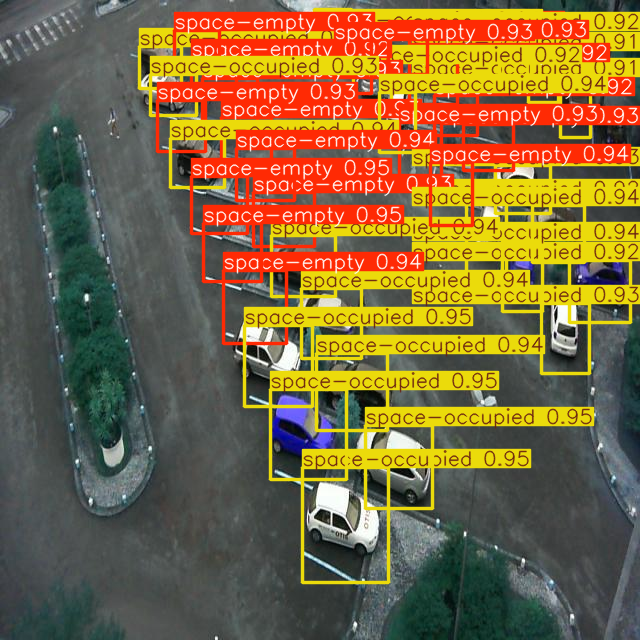

In [9]:
# Run YOLO detection on an image
results = model.predict(
    source='/content/2013-03-21_07_40_02_jpg.rf.7865ac6631f902692a2f410dbf4a7a1e.jpg',
    conf=0.25
)

# Show result inside notebook
from IPython.display import display
display(results[0].plot())


image 1/1 /content/2013-03-21_07_40_02_jpg.rf.7865ac6631f902692a2f410dbf4a7a1e.jpg: 640x640 18 space-emptys, 22 space-occupieds, 227.4ms
Speed: 7.0ms preprocess, 227.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Success: Navigation path to the nearest empty spot created.


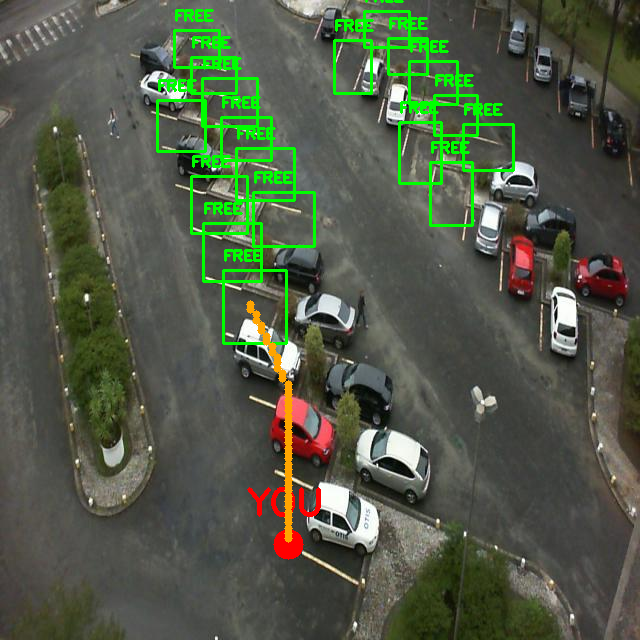

In [12]:
import cv2
import numpy as np
import heapq
from google.colab.patches import cv2_imshow

# A* Navigation Engine
def a_star_navigation(grid, start, goal):

    # A* algorithm to find the shortest path on a coordinate grid.

    neighbors = [(0,1),(0,-1),(1,0),(-1,0),(1,1),(1,-1),(-1,1),(-1,-1)]
    close_set = set()
    came_from = {}
    gscore = {start: 0}

    # Heuristic: Euclidean distance to the goal
    fscore = {start: np.sqrt((start[0]-goal[0])**2 + (start[1]-goal[1])**2)}
    oheap = []
    heapq.heappush(oheap, (fscore[start], start))

    while oheap:
        current = heapq.heappop(oheap)[1]
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            return path[::-1]

        close_set.add(current)
        for i, j in neighbors:
            neighbor = current[0] + i, current[1] + j
            if 0 <= neighbor[0] < grid.shape[0] and 0 <= neighbor[1] < grid.shape[1]:

                # Check if the grid cell is an obstacle (1 = occupied/blocked)
                if grid[neighbor[0]][neighbor[1]] == 1: continue
            else: continue

            move_cost = np.sqrt(i**2 + j**2)
            tentative_g_score = gscore[current] + move_cost

            if neighbor in close_set and tentative_g_score >= gscore.get(neighbor, 0): continue
            if tentative_g_score < gscore.get(neighbor, 0) or neighbor not in [i[1] for i in oheap]:
                came_from[neighbor] = current
                gscore[neighbor] = tentative_g_score
                fscore[neighbor] = tentative_g_score + np.sqrt((neighbor[0]-goal[0])**2 + (neighbor[1]-goal[1])**2)
                heapq.heappush(oheap, (fscore[neighbor], neighbor))
    return None

# Your specific image path
image_path = '/content/2013-03-21_07_40_02_jpg.rf.7865ac6631f902692a2f410dbf4a7a1e.jpg'

# Run YOLO with a slightly higher confidence to ensure spots are actually empty
results = model.predict(source=image_path, conf=0.30, save=False)

output_img = results[0].orig_img.copy()
h, w, _ = output_img.shape
grid_res = 120
grid = np.zeros((grid_res, grid_res), dtype=np.uint8)

# Define "YOU" position (Bottom center of the image)
user_y_ratio, user_x_ratio = 0.85, 0.45
my_start_node = (int(user_y_ratio * grid_res), int(user_x_ratio * grid_res))

available_spots = []

for box in results[0].boxes:
    label_id = int(box.cls[0])
    label_name = model.names[label_id].lower()

    # STRICT FILTER: Only proceed if the label is 'empty'
    # This ignores any box labeled as 'occupied' or 'car'
    if "empty" in label_name:
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Calculate the center of the empty spot
        center_node = (int(((y1+y2)/2)*(grid_res/h)), int(((x1+x2)/2)*(grid_res/w)))
        available_spots.append(center_node)

        # Visual feedback: Draw green boxes for truly empty spots
        cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(output_img, "FREE", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Navigation logic for the nearest empty spot
if available_spots:

    # Sort detected empty spots by distance to the user
    available_spots.sort(key=lambda s: (s[0]-my_start_node[0])**2 + (s[1]-my_start_node[1])**2)

    # Calculate path to the closest empty spot
    best_path = a_star_navigation(grid, my_start_node, available_spots[0])

    if best_path:

        # Draw "YOU" marker (Red circle)
        start_px = (int(user_x_ratio * w), int(user_y_ratio * h))
        cv2.circle(output_img, start_px, 15, (0, 0, 255), -1)
        cv2.putText(output_img, "YOU", (start_px[0]-40, start_px[1]-30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

        # Draw the navigation path(Orange dots)
        for p in best_path:
            px_x, px_y = int(p[1] * (w / grid_res)), int(p[0] * (h / grid_res))
            cv2.circle(output_img, (px_x, px_y), 4, (0, 165, 255), -1)

        print("Success: Navigation path to the nearest empty spot created.")
    else:
        print("Error: Pathfinding failed.")
else:
    print("Warning: No empty spots detected. All spots might be occupied.")

# Display the final processed image
cv2_imshow(output_img)